In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/xgtutorial.csv')
df

,Unnamed: 0,minute,team,xG,player,result
0,0,1,Southampton,0.105402,Nathan Redmond,BlockedShot
1,1,2,Southampton,0.136320,Jan Bednarek,BlockedShot
2,2,2,Southampton,0.037217,Oriol Romeu,BlockedShot
3,3,2,Southampton,0.021404,James Ward-Prowse,BlockedShot
4,4,3,Southampton,0.066363,Pierre-Emile Højbjerg,BlockedShot
5,5,9,Southampton,0.363826,Nathan Redmond,SavedShot
6,6,11,Southampton,0.354095,Shane Long,Goal
7,7,17,Southampton,0.036274,Nathan Redmond,MissedShots
8,8,21,Southampton,0.076804,Danny Ings,MissedShots
9,9,23,Southampton,0.380378,Shane Long,SavedShot


In [3]:
visitante_xG = [0]
mandante_xG = [0]
visitante_min = [0]
mandante_min = [0]

mandante = df['team'].iloc[0]
visitante = df['team'].iloc[-1]

for x in range(len(df['xG'])):
    if df['team'][x] == visitante:
        visitante_xG.append(df['xG'][x])
        visitante_min.append(df['minute'][x])
    else:
        mandante_xG.append(df['xG'][x])
        mandante_min.append(df['minute'][x])


In [6]:
def numsCumulativeSum(nums_list):
    return [sum(nums_list[:i+1]) for i in range(len(nums_list))]

In [8]:
visitanteCumulative = numsCumulativeSum(visitante_xG)
mandanteCumulative = numsCumulativeSum(mandante_xG)

In [9]:
visitante_total = round(visitanteCumulative[-1], 2)
mandante_total = round(mandanteCumulative[-1], 2)

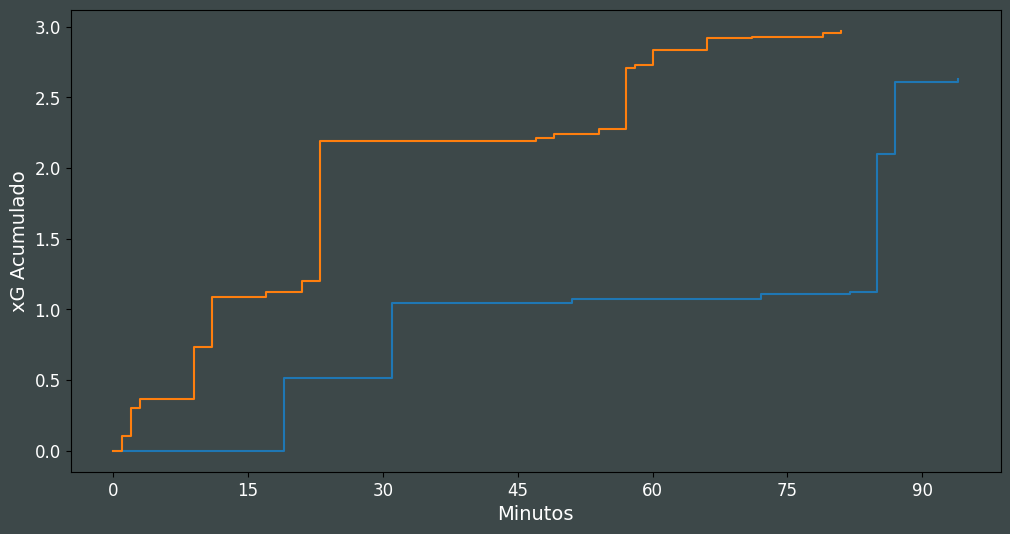

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.set_facecolor('#3d4849')
ax.patch.set_facecolor('#3d4849')

plt.xticks([0, 15, 30, 45, 60, 75, 90], color='white', fontsize=12)
plt.yticks(color='white', fontsize=12)

plt.xlabel("Minutos", fontsize=14, color='white')
plt.ylabel('xG Acumulado', fontsize=14, color='white')

ax.step(x=visitante_min, y=visitanteCumulative, where='post')
ax.step(x=mandante_min, y=mandanteCumulative, where='post')